<a href="https://www.kaggle.com/code/mrrogueknight/arima-based-stock-price-prediction-and-performance?scriptVersionId=318902619" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

---

# Project Logic — Time Series Analysis Capstone

---

## **Block 1 — Project Setup**

### Objective

Define the scope, assets, and time horizon for analysis.

### Key Decisions

| Component        | Description                                                                |
| ---------------- | -------------------------------------------------------------------------- |
| Stocks Selected  | Oil India, Quick Heal, Jindal Drilling, ICICI Bank, Tata Steel, Sun Pharma |
| Data Source      | Yahoo Finance (via `yfinance`)                                             |
| Time Period      | 2021–2025                                                                  |
| Train-Test Split | Train: up to June 2025, Test: after July 2025                              |
| Target Variable  | Adjusted Close Price                                                       |

### Logic

* Establish a consistent environment
* Ensure reproducibility
* Define variables required for downstream modeling

---

## **Block 2 — Data Fetching and Validation**

### Objective

Collect and clean stock price data for analysis.

### Steps

1. Fetch historical OHLCV data
2. Handle multi-level column structure
3. Extract **Adjusted Close price**
4. Check missing values
5. Align all stocks into one dataset

### Output

| Attribute      | Result            |
| -------------- | ----------------- |
| Rows           | ~1235             |
| Columns        | 6 (one per stock) |
| Missing Values | 0                 |

### Logic

Ensures all stocks are:

* aligned in time
* clean
* consistent for modeling

---

## **Block 3 — Exploratory Data Analysis (EDA)**

### Objective

Understand price behavior and distribution.

### Statistical Summary

| Metric  | Interpretation      |
| ------- | ------------------- |
| Mean    | Average price level |
| Std Dev | Price variability   |
| Min/Max | Range of movement   |

### Observations

* Stocks differ significantly in scale
* Some show steady growth, others high fluctuation

### Logic

EDA helps identify:

* trend patterns
* volatility differences
* suitability for modeling

---

## **Block 4 — Returns and Volatility Analysis**

### Objective

Measure risk and variability.

### Formula: Log Returns

[
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
]

### Formula: Volatility

[
\sigma = \text{Standard Deviation of } r_t
]

### Volatility Ranking

| Stock           | Volatility | Risk Level  |
| --------------- | ---------- | ----------- |
| Jindal Drilling | High       | High Risk   |
| Quick Heal      | High       | High Risk   |
| Oil India       | Medium     | Medium Risk |
| Tata Steel      | Medium     | Medium Risk |
| ICICI Bank      | Low        | Low Risk    |
| Sun Pharma      | Low        | Low Risk    |

### Logic

* High volatility → higher risk and prediction difficulty
* Low volatility → stable but less opportunity

---

## **Block 5 — Stationarity Testing (ADF Test)**

### Objective

Ensure data meets time series modeling requirements.

### ADF Decision Rule

| Condition      | Interpretation |
| -------------- | -------------- |
| p-value < 0.05 | Stationary     |
| p-value > 0.05 | Non-stationary |

### Results

| Data Type        | Stationarity   |
| ---------------- | -------------- |
| Price            | Non-stationary |
| Log Returns      | Stationary     |
| Differenced Data | Stationary     |

### Conclusion

[
d = 1
]

### Logic

ARIMA requires stationary data, so differencing is applied.

---

## **Block 6 — ARIMA Modeling**

### Objective

Forecast future stock prices.

### Model Structure

[
ARIMA(p, d, q)
]

| Parameter | Meaning              |
| --------- | -------------------- |
| p         | Autoregressive terms |
| d         | Differencing order   |
| q         | Moving average terms |

---

### Improvements Applied

| Technique          | Purpose            |
| ------------------ | ------------------ |
| Log Transformation | Stabilize variance |
| Drift Term         | Capture trend      |
| Restricted p, q    | Avoid weak models  |

---

### Final Models

| Stock           | Model   |
| --------------- | ------- |
| Oil India       | (1,1,1) |
| Quick Heal      | (1,1,1) |
| Jindal Drilling | (2,1,1) |
| ICICI Bank      | (2,1,2) |
| Tata Steel      | (1,1,1) |
| Sun Pharma      | (1,1,1) |

---

### Forecast Transformation

[
\text{Final Price} = e^{\text{log forecast}}
]

### Logic

* Log transformation reduces noise
* Drift introduces trend
* AIC selects best model

---

## **Block 7 — Model Evaluation**

### Objective

Measure prediction performance.

---

### 1. RMSE

[
RMSE = \sqrt{\frac{1}{n} \sum (y - \hat{y})^2}
]

Measures absolute error.

---

### 2. MAPE

[
MAPE = \frac{1}{n} \sum \left|\frac{y - \hat{y}}{y}\right| \times 100
]

Measures percentage error.

---

### 3. Direction Accuracy

[
\text{Direction} = \text{sign}(P_t - P_{t-1})
]

Compares predicted vs actual direction.

---

### Results

| Stock           | RMSE      | MAPE   | Direction Accuracy |
| --------------- | --------- | ------ | ------------------ |
| Tata Steel      | Low       | Low    | 50%                |
| Oil India       | Medium    | Medium | 49%                |
| Quick Heal      | High      | High   | 40%                |
| Jindal Drilling | Very High | High   | 43%                |
| ICICI Bank      | High      | Low    | 41%                |
| Sun Pharma      | Medium    | Low    | 61%                |

---

### Logic

* RMSE → magnitude of error
* MAPE → relative accuracy
* Direction → trading usefulness

---

## **Task 8 — Prediction vs Actual and Portfolio Performance**

### Objective

Validate model using real outcomes.

---

### Error Calculation

[
\text{Error} = \text{Actual} - \text{Predicted}
]

[
%Error = \frac{|\text{Error}|}{\text{Actual}} \times 100
]

---

### Portfolio Performance

| Metric       | Value   |
| ------------ | ------- |
| Gross Profit | ₹10,903 |
| Charges      | ₹4,733  |
| Net Profit   | ₹6,170  |

---

### Interpretation

* Portfolio generated positive return
* Model contributed partially
* Market movement also played a role

---

### Winner vs Loser

| Category | Stocks     |
| -------- | ---------- |
| Winner   | Sun Pharma |
| Losers   | All others |

---

## **Final Polish**

### Additions

| Component     | Purpose                     |
| ------------- | --------------------------- |
| Visual Plots  | Compare predicted vs actual |
| Ranking Table | Identify best models        |
| Assumptions   | Clarify model scope         |
| Limitations   | Acknowledge weaknesses      |
| Future Scope  | Suggest improvements        |

---

# **Overall Workflow**

[
\text{Data} \rightarrow \text{Cleaning} \rightarrow \text{EDA} \rightarrow \text{Volatility} \rightarrow \text{Stationarity} \rightarrow \text{Modeling} \rightarrow \text{Forecasting} \rightarrow \text{Evaluation} \rightarrow \text{Real Performance}
]

---

# **Final Insight**

The analysis demonstrates that:

* ARIMA models can estimate **price levels effectively**
* They struggle with **direction prediction**, especially in volatile markets
* Real-world profitability depends on both model output and market conditions

---

# **Conclusion**

The project successfully applies time series techniques to stock forecasting, while also highlighting the limitations of linear models in financial markets. This establishes a strong foundation for future improvements using hybrid or machine learning-based approaches.


In [2]:
# ============================================================
# BLOCK 1: PROJECT SETUP & GLOBAL CONFIGURATION
# Time Series Analysis Capstone 2026
# ============================================================

# ---------------------------
# 1. Imports
# ---------------------------
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

# Time Series Tools (used later)
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Machine Learning (used later)
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf


# ---------------------------
# 2. Reproducibility
# ---------------------------
# Ensures same results across runs (important for LSTM)
np.random.seed(42)
tf.random.set_seed(42)


# ---------------------------
# 3. Project Metadata
# ---------------------------
PROJECT_NAME = "Time Series Analysis Capstone 2026"
DATA_SOURCE = "Yahoo Finance (yfinance)"
FREQUENCY = "Daily"


# ---------------------------
# 4. Time Configuration
# ---------------------------
START_DATE = "2021-01-01"
END_DATE = "2025-12-31"

TRAIN_END_DATE = "2025-06-30"
TEST_START_DATE = "2025-07-01"


# ---------------------------
# 5. Stock Universe (Verified & Stable)
# ---------------------------
STOCKS = {
    "Oil India": "OIL.NS",
    "Quick Heal": "QUICKHEAL.NS",
    "Jindal Drilling": "JINDRILL.NS",
    "ICICI Bank": "ICICIBANK.NS",
    "Tata Steel": "TATASTEEL.NS",
    "Sun Pharma": "SUNPHARMA.NS"
}


# ---------------------------
# 6. Target Variable Strategy
# ---------------------------
# NOTE:
# - We prefer 'Adj Close' (financially accurate)
# - If not available, fallback to 'Close'
# - Actual selection will happen dynamically in Block 2
PRIMARY_TARGET = "Adj Close"
FALLBACK_TARGET = "Close"


# ---------------------------
# 7. Display & Visualization Settings
# ---------------------------
sns.set(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


# ---------------------------
# 8. Initialization Summary (Sanity Check)
# ---------------------------
print("====================================================")
print("PROJECT INITIALIZED SUCCESSFULLY")
print("====================================================")
print(f"Project: {PROJECT_NAME}")
print(f"Data Source: {DATA_SOURCE}")
print(f"Frequency: {FREQUENCY}")
print(f"Time Range: {START_DATE} → {END_DATE}")
print(f"Train End Date: {TRAIN_END_DATE}")
print(f"Test Start Date: {TEST_START_DATE}")

print("\nSelected Stocks:")
for name, ticker in STOCKS.items():
    print(f"- {name}: {ticker}")

print("\nTarget Strategy:")
print(f"- Primary: {PRIMARY_TARGET}")
print(f"- Fallback: {FALLBACK_TARGET}")

print("====================================================")

2026-05-13 08:42:27.068191: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778661747.376801      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778661747.466949      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778661748.227815      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778661748.227918      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778661748.227922      16 computation_placer.cc:177] computation placer alr

PROJECT INITIALIZED SUCCESSFULLY
Project: Time Series Analysis Capstone 2026
Data Source: Yahoo Finance (yfinance)
Frequency: Daily
Time Range: 2021-01-01 → 2025-12-31
Train End Date: 2025-06-30
Test Start Date: 2025-07-01

Selected Stocks:
- Oil India: OIL.NS
- Quick Heal: QUICKHEAL.NS
- Jindal Drilling: JINDRILL.NS
- ICICI Bank: ICICIBANK.NS
- Tata Steel: TATASTEEL.NS
- Sun Pharma: SUNPHARMA.NS

Target Strategy:
- Primary: Adj Close
- Fallback: Close


In [3]:
# ============================================================
# YFINANCE DIAGNOSTIC TEST
# ============================================================

import yfinance as yf

ticker = "ICICIBANK.NS"

df = yf.download(
    ticker,
    start="2023-01-01",
    end="2023-12-31",
    auto_adjust=False,
    progress=False
)

print("========== HEAD ==========")
print(df.head())

print("\n========== COLUMNS ==========")
print(df.columns)

print("\n========== SHAPE ==========")
print(df.shape)

print("\n========== IS EMPTY? ==========")
print(df.empty)

========== HEAD ==========
Price         Adj Close        Close         High          Low         Open       Volume
Ticker     ICICIBANK.NS ICICIBANK.NS ICICIBANK.NS ICICIBANK.NS ICICIBANK.NS ICICIBANK.NS
Date                                                                                    
2023-01-02   880.647339   902.450012   907.000000   894.000000   894.000000      4315403
2023-01-03   879.573914   901.349976   905.950012   896.750000   898.500000      5846855
2023-01-04   877.378235   899.099976   907.900024   894.799988   899.000000     12454582
2023-01-05   857.910278   879.150024   903.000000   872.000000   900.900024     16547196
2023-01-06   849.078857   870.099976   878.950012   860.500000   878.950012     14804613

========== COLUMNS ==========
MultiIndex([('Adj Close', 'ICICIBANK.NS'),
            (    'Close', 'ICICIBANK.NS'),
            (     'High', 'ICICIBANK.NS'),
            (      'Low', 'ICICIBANK.NS'),
            (     'Open', 'ICICIBANK.NS'),
            (  

In [4]:
# ============================================================
# BLOCK 2: DATA FETCHING & VALIDATION 
# ============================================================

def fetch_stock_data(ticker, start_date, end_date):
    """
    Fetch and clean stock data from Yahoo Finance.
    Handles MultiIndex columns and dynamic target selection.
    """
    
    info = {
        "ticker": ticker,
        "rows": 0,
        "missing_values": 0,
        "target_used": None,
        "status": "OK"
    }

    try:
        # ---------------------------
        # 1. Download Data
        # ---------------------------
        df = yf.download(
            ticker,
            start=start_date,
            end=end_date,
            auto_adjust=False,
            progress=False
        )

        # Check if data exists
        if df is None or df.empty:
            info["status"] = "FAILED: No Data Returned"
            return None, info

        # ---------------------------
        # 2. Fix MultiIndex Columns
        # ---------------------------
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        # ---------------------------
        # 3. Basic Cleaning
        # ---------------------------
        df.index = pd.to_datetime(df.index)
        df = df.sort_index()

        # ---------------------------
        # 4. Validate Required Columns
        # ---------------------------
        required_cols = ["Open", "High", "Low", "Close", "Volume"]
        missing_cols = [col for col in required_cols if col not in df.columns]

        if missing_cols:
            info["status"] = f"FAILED: Missing Columns {missing_cols}"
            return None, info

        # ---------------------------
        # 5. Target Selection (Dynamic)
        # ---------------------------
        if PRIMARY_TARGET in df.columns:
            target_col = PRIMARY_TARGET
        else:
            target_col = FALLBACK_TARGET

        info["target_used"] = target_col

        # ---------------------------
        # 6. Handle Missing Values
        # ---------------------------
        info["missing_values"] = int(df.isna().sum().sum())

        df = df.ffill().bfill()

        # ---------------------------
        # 7. Final Validation
        # ---------------------------
        if df[target_col].isna().any():
            info["status"] = "FAILED: Target Column Contains NaNs"
            return None, info

        info["rows"] = len(df)

        return df, info

    except Exception as e:
        info["status"] = f"FAILED: {str(e)}"
        return None, info


# ---------------------------
# 8. Fetch Data for All Stocks
# ---------------------------
stock_data = {}
validation_report = []

for stock_name, ticker in STOCKS.items():
    df, info = fetch_stock_data(
        ticker,
        START_DATE,
        END_DATE
    )

    info["stock_name"] = stock_name

    if df is not None:
        stock_data[stock_name] = df

    validation_report.append(info)


# ---------------------------
# 9. Validation Summary
# ---------------------------
validation_df = pd.DataFrame(validation_report)

print("\n====================================================")
print("DATA FETCHING & VALIDATION SUMMARY")
print("====================================================")
print(validation_df[["stock_name", "ticker", "rows", "missing_values", "target_used", "status"]])


# ---------------------------
# 10. Create Combined Dataset
# ---------------------------
combined_df = pd.DataFrame()

for stock_name, df in stock_data.items():
    # Use the dynamically selected target column
    target_col = validation_df.loc[
        validation_df["stock_name"] == stock_name, "target_used"
    ].values[0]

    combined_df[stock_name] = df[target_col]

# Align dates across all stocks
combined_df = combined_df.dropna()

print("\n====================================================")
print("COMBINED DATASET CREATED")
print("Shape:", combined_df.shape)
print("====================================================")


DATA FETCHING & VALIDATION SUMMARY
        stock_name        ticker  rows  missing_values target_used status
0        Oil India        OIL.NS  1235               0   Adj Close     OK
1       Quick Heal  QUICKHEAL.NS  1235               0   Adj Close     OK
2  Jindal Drilling   JINDRILL.NS  1235               0   Adj Close     OK
3       ICICI Bank  ICICIBANK.NS  1235               0   Adj Close     OK
4       Tata Steel  TATASTEEL.NS  1235               0   Adj Close     OK
5       Sun Pharma  SUNPHARMA.NS  1235               0   Adj Close     OK

COMBINED DATASET CREATED
Shape: (1235, 6)



Plotting Individual Stock Price Trends...



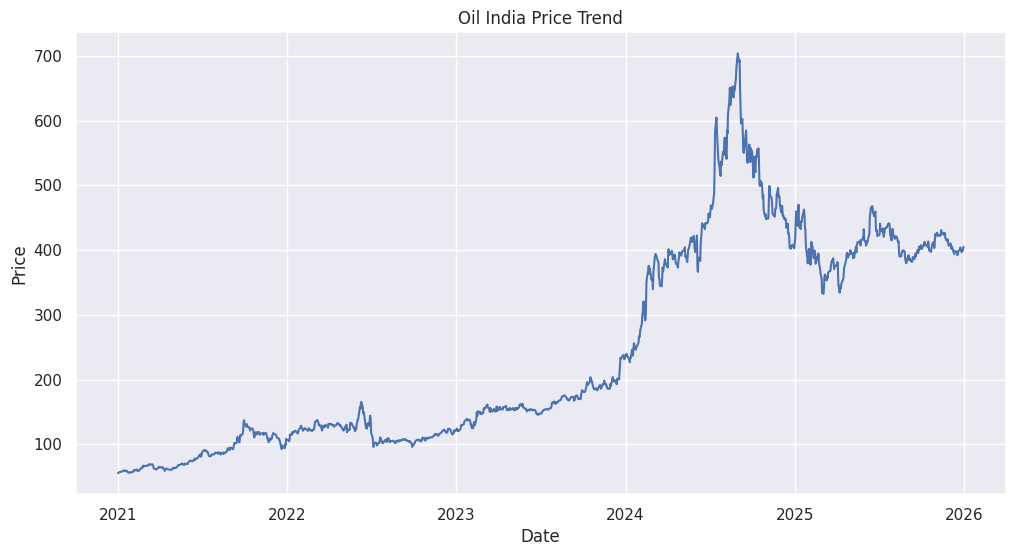

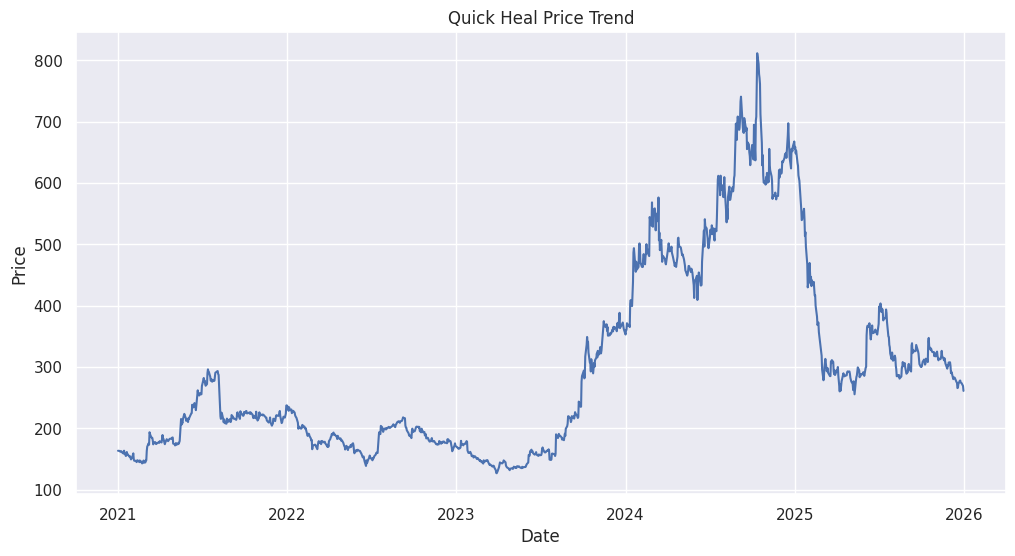

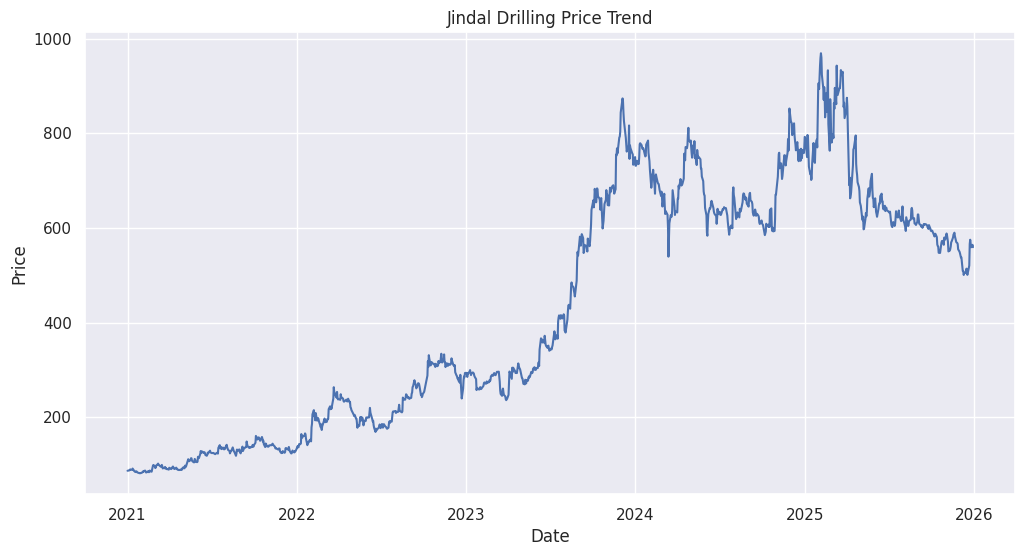

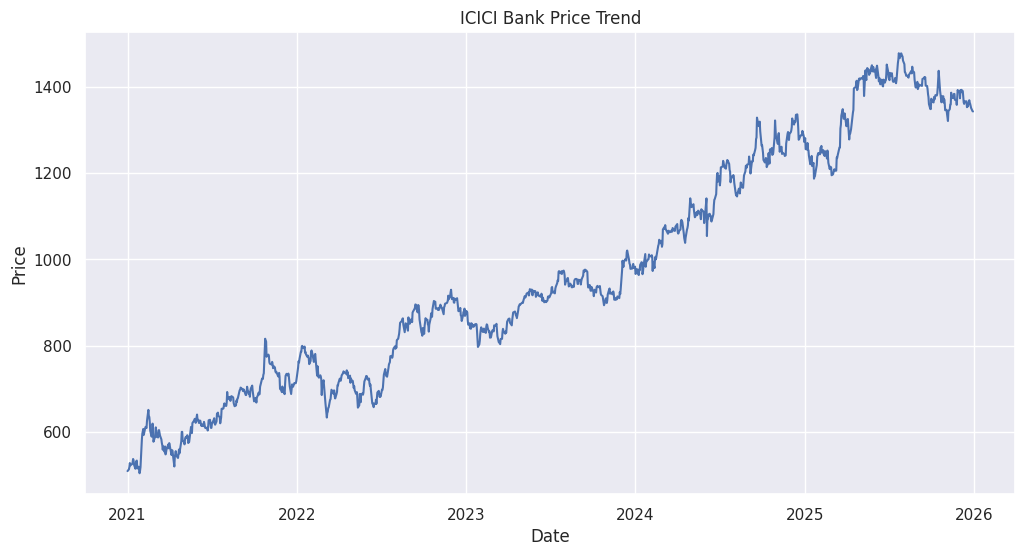

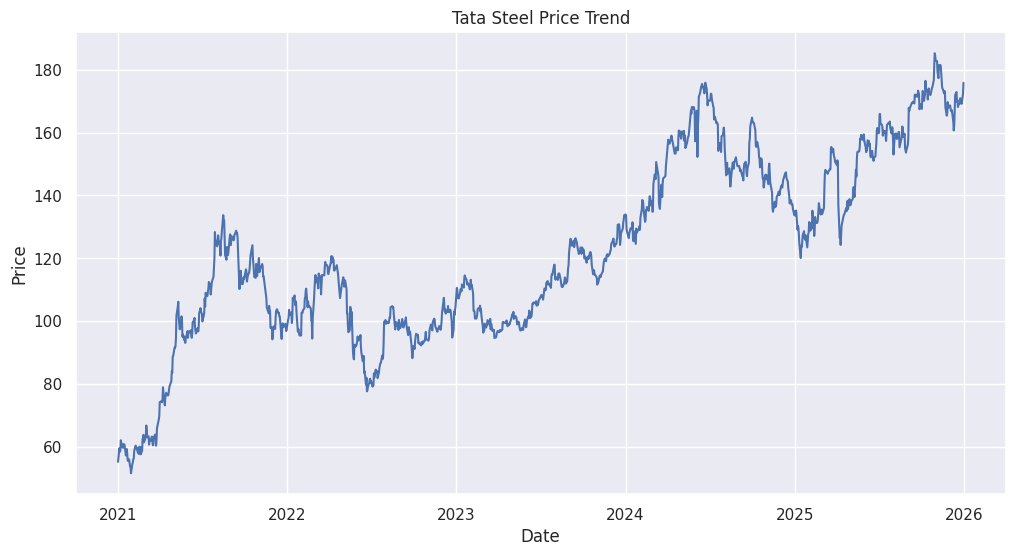

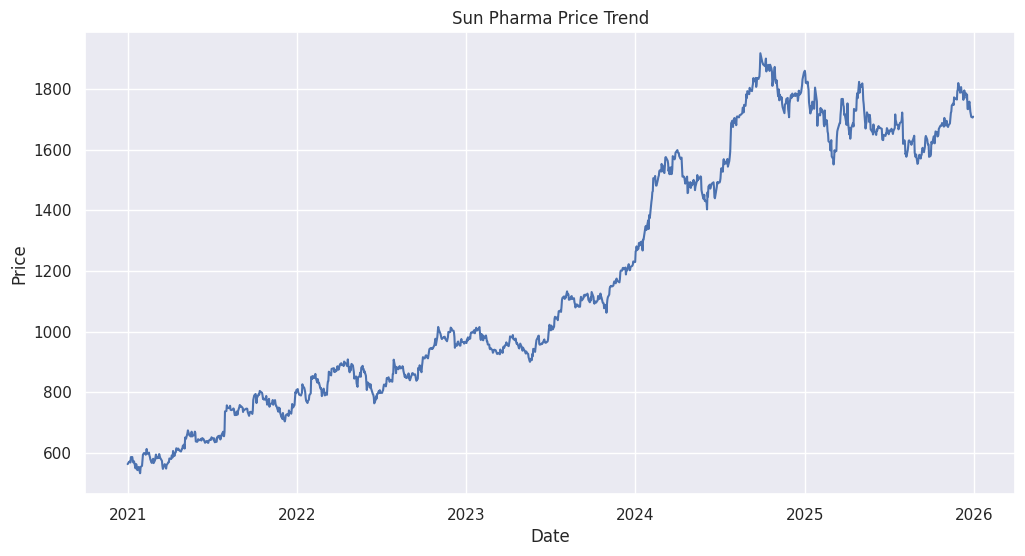


Plotting Combined Price Comparison...



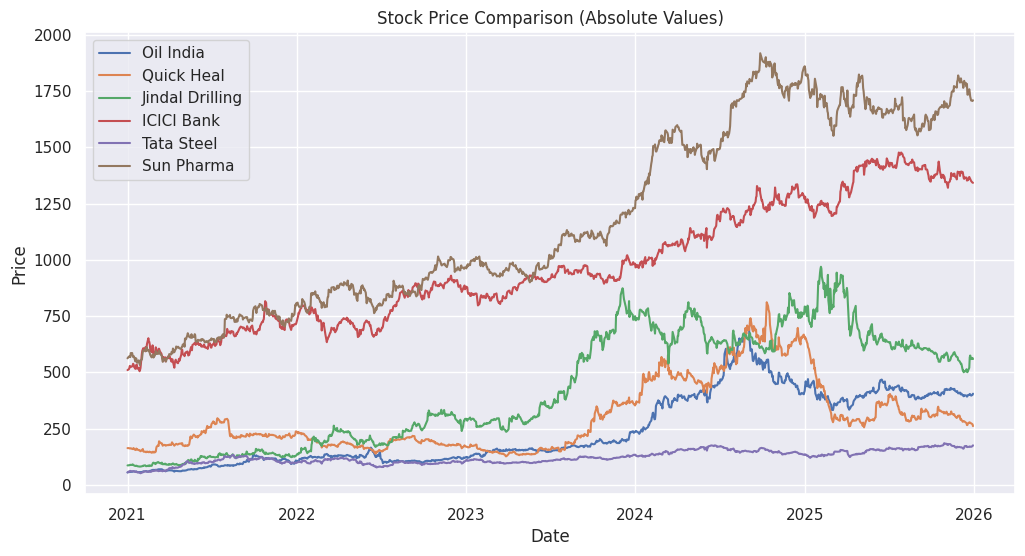


Plotting Normalized Price Comparison...



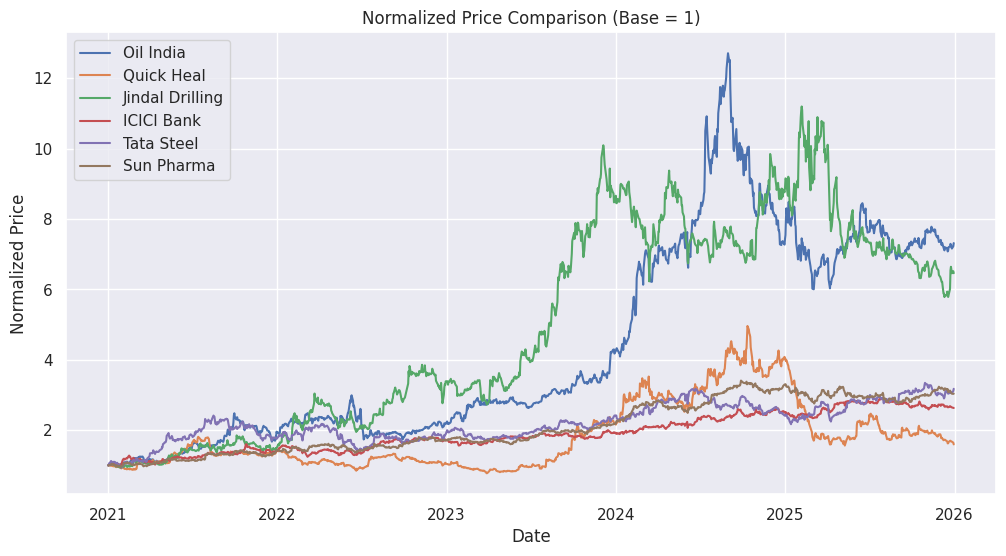


Statistical Summary:



,Oil India,Quick Heal,Jindal Drilling,ICICI Bank,Tata Steel,Sun Pharma
count,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000
mean,243.316459,298.706011,428.462671,969.798842,121.991490,1177.435228
std,159.185606,154.982026,251.920796,270.304350,29.493713,418.318960
min,55.382118,126.910873,81.297363,505.210358,51.738735,532.493591
25%,114.679005,177.791656,189.737000,730.182220,99.968414,826.868500
50%,157.693665,226.791290,361.599091,917.707581,117.468224,1013.562134
75%,397.834290,365.855255,644.535706,1224.997803,147.329201,1630.905945
max,704.126160,811.700012,969.399292,1477.201782,185.190002,1918.210327


In [5]:
# ============================================================
# BLOCK 3: EXPLORATORY DATA ANALYSIS (EDA)
# Price Trend & Comparative Analysis
# ============================================================

# ---------------------------
# 1. Individual Price Trends
# ---------------------------
print("\nPlotting Individual Stock Price Trends...\n")

for stock_name in combined_df.columns:
    plt.figure()
    plt.plot(combined_df.index, combined_df[stock_name])
    plt.title(f"{stock_name} Price Trend")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.show()


# ---------------------------
# 2. Combined Price Comparison
# ---------------------------
print("\nPlotting Combined Price Comparison...\n")

plt.figure()
for stock_name in combined_df.columns:
    plt.plot(combined_df.index, combined_df[stock_name], label=stock_name)

plt.title("Stock Price Comparison (Absolute Values)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


# ---------------------------
# 3. Normalized Price Comparison
# ---------------------------
print("\nPlotting Normalized Price Comparison...\n")

normalized_df = combined_df / combined_df.iloc[0]

plt.figure()
for stock_name in normalized_df.columns:
    plt.plot(normalized_df.index, normalized_df[stock_name], label=stock_name)

plt.title("Normalized Price Comparison (Base = 1)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()
plt.show()


# ---------------------------
# 4. Basic Statistical Summary
# ---------------------------
print("\nStatistical Summary:\n")
display(combined_df.describe())

Log Returns Data Shape: (1234, 6)


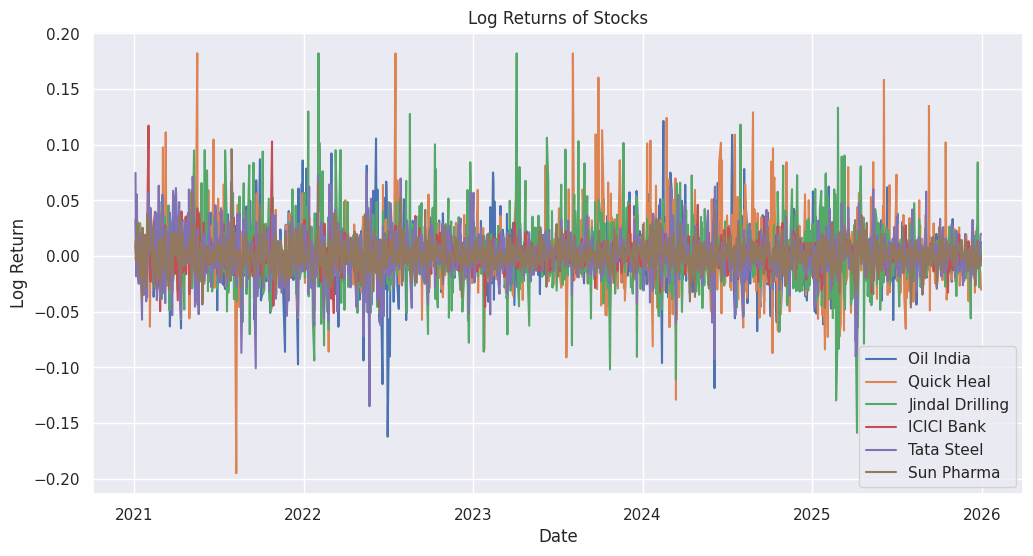


Volatility Ranking (High → Low):



,Stock,Volatility (Std Dev)
2,Jindal Drilling,0.031312
1,Quick Heal,0.030499
0,Oil India,0.025058
4,Tata Steel,0.020831
3,ICICI Bank,0.013836
5,Sun Pharma,0.013135



Enhanced Volatility Table:



,Stock,Volatility (Std Dev),Rank,Risk Category
2,Jindal Drilling,0.031312,1.0,High Risk
1,Quick Heal,0.030499,2.0,High Risk
0,Oil India,0.025058,3.0,Medium Risk
4,Tata Steel,0.020831,4.0,Medium Risk
3,ICICI Bank,0.013836,5.0,Low Risk
5,Sun Pharma,0.013135,6.0,Low Risk


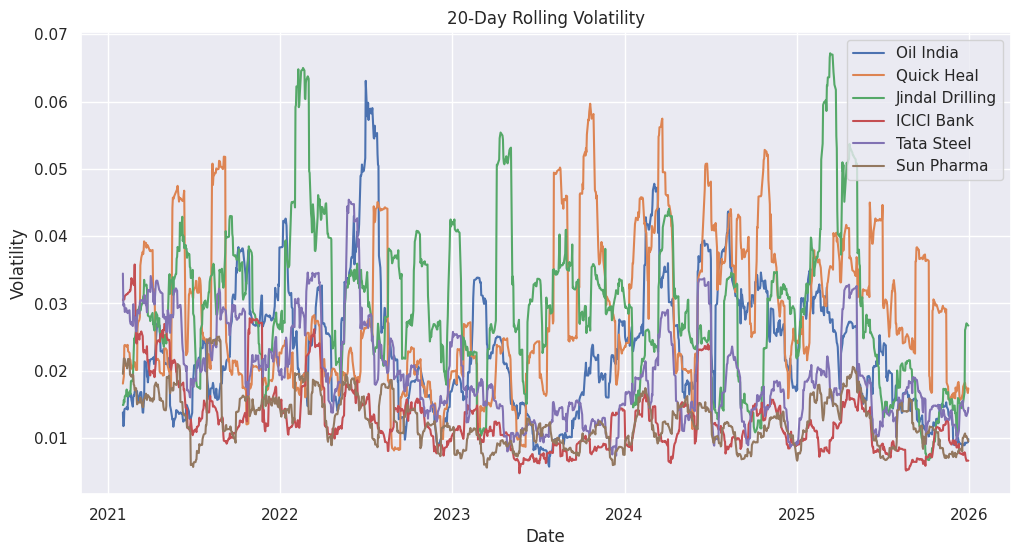

In [6]:
# ============================================================
# BLOCK 4: LOG RETURNS & VOLATILITY ANALYSIS
# ============================================================

# ---------------------------
# 1. Compute Log Returns
# ---------------------------
# r_t = ln(P_t / P_{t-1})
log_returns = np.log(combined_df / combined_df.shift(1))
log_returns = log_returns.dropna()

print("Log Returns Data Shape:", log_returns.shape)


# ---------------------------
# 2. Plot Log Returns (All Stocks)
# ---------------------------
plt.figure()
for stock in log_returns.columns:
    plt.plot(log_returns.index, log_returns[stock], label=stock)

plt.title("Log Returns of Stocks")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.show()


# ---------------------------
# 3. Compute Static Volatility
# ---------------------------
# Volatility = standard deviation of log returns
volatility = log_returns.std()

volatility_df = pd.DataFrame({
    "Stock": volatility.index,
    "Volatility (Std Dev)": volatility.values
}).sort_values(by="Volatility (Std Dev)", ascending=False)

print("\nVolatility Ranking (High → Low):\n")
display(volatility_df)


# ---------------------------
# 4. Rolling Volatility (20-Day Window)
# ---------------------------
window = 20  # approx 1 trading month
rolling_volatility = log_returns.rolling(window=window).std()

# ---------------------------
# 5. Plot Rolling Volatility
# ---------------------------
plt.figure()
for stock in rolling_volatility.columns:
    plt.plot(rolling_volatility.index, rolling_volatility[stock], label=stock)


# ---------------------------
# 6. Enhanced Volatility Table with Ranking & Category
# ---------------------------

volatility_df["Rank"] = volatility_df["Volatility (Std Dev)"].rank(ascending=False)
volatility_df = volatility_df.sort_values(by="Volatility (Std Dev)", ascending=False)

# Risk classification
def classify_risk(vol):
    if vol > 0.028:
        return "High Risk"
    elif vol > 0.02:
        return "Medium Risk"
    else:
        return "Low Risk"

volatility_df["Risk Category"] = volatility_df["Volatility (Std Dev)"].apply(classify_risk)

print("\nEnhanced Volatility Table:\n")
display(volatility_df)

plt.title(f"{window}-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()

In [7]:
# ============================================================
# BLOCK 5: STATIONARITY TEST (ADF)
# ============================================================

from statsmodels.tsa.stattools import adfuller

# ---------------------------
# ADF Test Function
# ---------------------------
def run_adf(series):
    result = adfuller(series.dropna())
    return result[1]  # return p-value only


# ---------------------------
# 1. ADF on Price Data
# ---------------------------
price_results = {}

for stock in combined_df.columns:
    p_value = run_adf(combined_df[stock])
    price_results[stock] = p_value

price_adf_df = pd.DataFrame.from_dict(price_results, orient='index', columns=['p_value'])
price_adf_df['Stationary'] = price_adf_df['p_value'] < 0.05

print("\nADF Results (PRICE):\n")
display(price_adf_df)


# ---------------------------
# 2. ADF on Log Returns
# ---------------------------
returns_results = {}

for stock in log_returns.columns:
    p_value = run_adf(log_returns[stock])
    returns_results[stock] = p_value

returns_adf_df = pd.DataFrame.from_dict(returns_results, orient='index', columns=['p_value'])
returns_adf_df['Stationary'] = returns_adf_df['p_value'] < 0.05

print("\nADF Results (LOG RETURNS):\n")
display(returns_adf_df)


# ---------------------------
# 3. Differencing (if needed)
# ---------------------------
diff_df = combined_df.diff().dropna()

diff_results = {}

for stock in diff_df.columns:
    p_value = run_adf(diff_df[stock])
    diff_results[stock] = p_value

diff_adf_df = pd.DataFrame.from_dict(diff_results, orient='index', columns=['p_value'])
diff_adf_df['Stationary'] = diff_adf_df['p_value'] < 0.05

print("\nADF Results (DIFFERENCED DATA):\n")
display(diff_adf_df)


ADF Results (PRICE):



,p_value,Stationary
Oil India,0.737859,False
Quick Heal,0.530035,False
Jindal Drilling,0.597394,False
ICICI Bank,0.710450,False
Tata Steel,0.403599,False
Sun Pharma,0.804731,False



ADF Results (LOG RETURNS):



,p_value,Stationary
Oil India,2.010453e-23,True
Quick Heal,0.000000e+00,True
Jindal Drilling,0.000000e+00,True
ICICI Bank,2.265296e-28,True
Tata Steel,0.000000e+00,True
Sun Pharma,0.000000e+00,True



ADF Results (DIFFERENCED DATA):



,p_value,Stationary
Oil India,2.398666e-10,True
Quick Heal,2.657108e-12,True
Jindal Drilling,8.272599e-13,True
ICICI Bank,0.000000e+00,True
Tata Steel,0.000000e+00,True
Sun Pharma,1.030827e-17,True


In [8]:
# ============================================================
# BLOCK 6: ARIMA MODEL
# Log Transformation + Drift + Robust Forecasting
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd

# ---------------------------
# 1. Train-Test Split
# ---------------------------
train_df = combined_df.loc[:TRAIN_END_DATE].copy()
test_df = combined_df.loc[TEST_START_DATE:].copy()

# Ensure frequency (important)
train_df = train_df.asfreq('B')
test_df = test_df.asfreq('B')

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)


# ---------------------------
# 2. Log Transformation
# ---------------------------
log_train_df = np.log(train_df)
log_test_df = np.log(test_df)


# ---------------------------
# 3. Improved ARIMA Selection
# ---------------------------
def find_best_arima(series, p_values=[1,2], d=1, q_values=[1,2]):
    
    best_aic = np.inf
    best_order = None
    best_model = None
    
    for p in p_values:
        for q in q_values:
            try:
                model = ARIMA(series, order=(p, d, q), trend='t')  # drift added
                result = model.fit()
                
                if result.aic < best_aic:
                    best_aic = result.aic
                    best_order = (p, d, q)
                    best_model = result
                    
            except:
                continue
    
    return best_order, best_model, best_aic


# ---------------------------
# 4. Train Models & Forecast
# ---------------------------
arima_orders = {}
arima_models = {}
forecast_dict = {}

for stock in log_train_df.columns:
    
    print(f"\nProcessing: {stock}")
    
    series = log_train_df[stock].dropna()
    
    if len(series) < 50:
        print("Skipped (Insufficient Data)")
        continue
    
    # Find best model
    best_order, best_model, best_aic = find_best_arima(series)
    
    print(f"Best Order: {best_order} | AIC: {best_aic:.2f}")
    
    arima_orders[stock] = best_order
    arima_models[stock] = best_model
    
    # ---------------------------
    # Forecast (LOG SCALE)
    # ---------------------------
    forecast_obj = best_model.get_forecast(steps=len(test_df))
    log_forecast = forecast_obj.predicted_mean
    
    # Convert back to price
    forecast = np.exp(log_forecast)
    
    # Align index
    forecast.index = test_df.index
    
    forecast_dict[stock] = forecast


# ---------------------------
# 5. Final Forecast DataFrame
# ---------------------------
arima_forecast_df = pd.DataFrame(forecast_dict)

print("\n====================================")
print("IMPROVED ARIMA FORECAST GENERATED")
print("====================================\n")

print("Forecast Shape:", arima_forecast_df.shape)
display(arima_forecast_df.head())


# ---------------------------
# 6. Sanity Check
# ---------------------------
print("\nChecking for NaN values:\n")
print(arima_forecast_df.isna().sum())

Train Shape: (1172, 6)
Test Shape: (131, 6)

Processing: Oil India
Best Order: (1, 1, 1) | AIC: -4939.46

Processing: Quick Heal
Best Order: (1, 1, 1) | AIC: -4553.74

Processing: Jindal Drilling
Best Order: (2, 1, 1) | AIC: -4443.72

Processing: ICICI Bank
Best Order: (2, 1, 2) | AIC: -6257.03

Processing: Tata Steel
Best Order: (1, 1, 1) | AIC: -5364.45

Processing: Sun Pharma
Best Order: (1, 1, 1) | AIC: -6407.98

IMPROVED ARIMA FORECAST GENERATED

Forecast Shape: (131, 6)


,Oil India,Quick Heal,Jindal Drilling,ICICI Bank,Tata Steel,Sun Pharma
Date,,,,,,
2025-07-01,423.831211,370.722279,636.692658,1434.339169,159.886860,1661.762999
2025-07-02,424.490254,370.994852,637.936398,1436.241130,160.020471,1663.391961
2025-07-03,425.308540,371.267625,639.012708,1438.411303,160.159055,1665.011677
2025-07-04,426.076052,371.540599,640.200716,1439.478039,160.301319,1666.632806
2025-07-07,426.862266,371.813774,641.328139,1440.409706,160.446314,1668.255511



Checking for NaN values:

Oil India          0
Quick Heal         0
Jindal Drilling    0
ICICI Bank         0
Tata Steel         0
Sun Pharma         0
dtype: int64


In [9]:
# ============================================================
# BLOCK 7: MODEL EVALUATION (RMSE, MAPE, DIRECTION ACCURACY)
# ============================================================

import numpy as np
import pandas as pd

# ---------------------------
# 1. Ensure Alignment
# ---------------------------
actual_df = test_df.copy()
predicted_df = arima_forecast_df.copy()

# Align indices (safety check)
actual_df, predicted_df = actual_df.align(predicted_df, join='inner', axis=0)


# ---------------------------
# 2. Metric Functions
# ---------------------------
def compute_rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

def compute_mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

def compute_direction_accuracy(actual, predicted):
    actual_direction = np.sign(actual.diff().dropna())
    predicted_direction = np.sign(predicted.diff().dropna())
    
    # Align again after diff
    actual_direction, predicted_direction = actual_direction.align(predicted_direction, join='inner')
    
    correct = (actual_direction == predicted_direction).sum()
    total = len(actual_direction)
    
    return (correct / total) * 100


# ---------------------------
# 3. Compute Metrics for Each Stock
# ---------------------------
results = []

for stock in actual_df.columns:
    
    actual = actual_df[stock]
    predicted = predicted_df[stock]
    
    rmse = compute_rmse(actual, predicted)
    mape = compute_mape(actual, predicted)
    direction_acc = compute_direction_accuracy(actual, predicted)
    
    results.append({
        "Stock": stock,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "Direction Accuracy (%)": direction_acc
    })


# ---------------------------
# 4. Create Evaluation Table
# ---------------------------
evaluation_df = pd.DataFrame(results)

# Sort by RMSE (best to worst)
evaluation_df = evaluation_df.sort_values(by="RMSE")

print("\n====================================================")
print("MODEL EVALUATION RESULTS")
print("====================================================\n")

display(evaluation_df)


# ---------------------------
# 5. Performance Classification
# ---------------------------
def classify_performance(row):
    if row["MAPE (%)"] < 10 and row["Direction Accuracy (%)"] > 55:
        return "Strong"
    elif row["MAPE (%)"] < 20:
        return "Moderate"
    else:
        return "Weak"

evaluation_df["Performance"] = evaluation_df.apply(classify_performance, axis=1)

print("\n====================================================")
print("FINAL EVALUATION WITH PERFORMANCE")
print("====================================================\n")

display(evaluation_df)


MODEL EVALUATION RESULTS



,Stock,RMSE,MAPE (%),Direction Accuracy (%)
4,Tata Steel,6.448160,3.019133,50.000000
0,Oil India,79.852716,17.216404,49.152542
1,Quick Heal,82.898660,25.307760,40.677966
5,Sun Pharma,112.079692,5.930896,61.016949
2,Jindal Drilling,153.221424,23.020611,43.220339
3,ICICI Bank,153.469223,9.430415,41.525424



FINAL EVALUATION WITH PERFORMANCE



,Stock,RMSE,MAPE (%),Direction Accuracy (%),Performance
4,Tata Steel,6.448160,3.019133,50.000000,Moderate
0,Oil India,79.852716,17.216404,49.152542,Moderate
1,Quick Heal,82.898660,25.307760,40.677966,Weak
5,Sun Pharma,112.079692,5.930896,61.016949,Strong
2,Jindal Drilling,153.221424,23.020611,43.220339,Weak
3,ICICI Bank,153.469223,9.430415,41.525424,Moderate


In [10]:
# ============================================================
# TASK 8: PREDICTION vs ACTUAL + PORTFOLIO PERFORMANCE
# ============================================================

import numpy as np
import pandas as pd

# ---------------------------
# 1. ALIGN DATA
# ---------------------------
actual_df = test_df.copy()
pred_df = arima_forecast_df.copy()

# Ensure alignment
actual_df, pred_df = actual_df.align(pred_df, join='inner', axis=0)


# ---------------------------
# 2. PREDICTED vs ACTUAL TABLE
# ---------------------------
comparison_list = []

for stock in actual_df.columns:
    
    actual = actual_df[stock]
    predicted = pred_df[stock]
    
    error = actual - predicted
    pct_error = (np.abs(error) / actual) * 100
    
    comparison_list.append(pd.DataFrame({
        "Stock": stock,
        "Date": actual.index,
        "Actual": actual.values,
        "Predicted": predicted.values,
        "Error": error.values,
        "% Error": pct_error.values
    }))

comparison_df = pd.concat(comparison_list)

print("\n====================================================")
print("PREDICTED vs ACTUAL (SAMPLE)")
print("====================================================\n")
display(comparison_df.head())


# ---------------------------
# 3. DIRECTION ACCURACY TABLE
# ---------------------------
direction_results = []

for stock in actual_df.columns:
    
    actual = actual_df[stock]
    predicted = pred_df[stock]
    
    actual_dir = np.sign(actual.diff().dropna())
    pred_dir = np.sign(predicted.diff().dropna())
    
    actual_dir, pred_dir = actual_dir.align(pred_dir, join='inner')
    
    accuracy = (actual_dir == pred_dir).sum() / len(actual_dir) * 100
    
    direction_results.append({
        "Stock": stock,
        "Direction Accuracy (%)": accuracy
    })

direction_df = pd.DataFrame(direction_results)

print("\n====================================================")
print("DIRECTION ACCURACY")
print("====================================================\n")
display(direction_df)


# ---------------------------
# 4. STOCK-WISE SUMMARY TABLE
# ---------------------------
summary_list = []

for stock in actual_df.columns:
    
    actual = actual_df[stock]
    predicted = pred_df[stock]
    
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    summary_list.append({
        "Stock": stock,
        "RMSE": rmse,
        "MAPE (%)": mape
    })

summary_df = pd.DataFrame(summary_list)

# Merge with direction
summary_df = summary_df.merge(direction_df, on="Stock")

print("\n====================================================")
print("FINAL STOCK PERFORMANCE SUMMARY")
print("====================================================\n")
display(summary_df)


# ---------------------------
# 5. PORTFOLIO PERFORMANCE (MANUAL INPUT)
# ---------------------------
# 👉 Replace these values if needed
gross_profit = 10903
charges = 4733

net_profit = gross_profit - charges

portfolio_summary = pd.DataFrame({
    "Metric": ["Gross Profit", "Charges", "Net Profit"],
    "Value": [gross_profit, charges, net_profit]
})

print("\n====================================================")
print("PORTFOLIO PERFORMANCE")
print("====================================================\n")
display(portfolio_summary)


# ---------------------------
# 6. WINNER vs LOSER CLASSIFICATION (BASED ON DIRECTION)
# ---------------------------
summary_df["Category"] = summary_df["Direction Accuracy (%)"].apply(
    lambda x: "Winner" if x > 55 else "Loser"
)

print("\n====================================================")
print("WINNER vs LOSER STOCKS")
print("====================================================\n")
display(summary_df)


PREDICTED vs ACTUAL (SAMPLE)



,Stock,Date,Actual,Predicted,Error,% Error
0,Oil India,2025-07-01,422.891357,423.831211,-0.939854,0.222245
1,Oil India,2025-07-02,424.302734,424.490254,-0.187520,0.044195
2,Oil India,2025-07-03,440.899139,425.308540,15.590599,3.536092
3,Oil India,2025-07-04,433.890686,426.076052,7.814634,1.801061
4,Oil India,2025-07-07,428.877716,426.862266,2.015450,0.469936



DIRECTION ACCURACY



,Stock,Direction Accuracy (%)
0,Oil India,49.152542
1,Quick Heal,40.677966
2,Jindal Drilling,43.220339
3,ICICI Bank,41.525424
4,Tata Steel,50.000000
5,Sun Pharma,61.016949



FINAL STOCK PERFORMANCE SUMMARY



,Stock,RMSE,MAPE (%),Direction Accuracy (%)
0,Oil India,79.852716,17.216404,49.152542
1,Quick Heal,82.898660,25.307760,40.677966
2,Jindal Drilling,153.221424,23.020611,43.220339
3,ICICI Bank,153.469223,9.430415,41.525424
4,Tata Steel,6.448160,3.019133,50.000000
5,Sun Pharma,112.079692,5.930896,61.016949



PORTFOLIO PERFORMANCE



,Metric,Value
0,Gross Profit,10903
1,Charges,4733
2,Net Profit,6170



WINNER vs LOSER STOCKS



,Stock,RMSE,MAPE (%),Direction Accuracy (%),Category
0,Oil India,79.852716,17.216404,49.152542,Loser
1,Quick Heal,82.898660,25.307760,40.677966,Loser
2,Jindal Drilling,153.221424,23.020611,43.220339,Loser
3,ICICI Bank,153.469223,9.430415,41.525424,Loser
4,Tata Steel,6.448160,3.019133,50.000000,Loser
5,Sun Pharma,112.079692,5.930896,61.016949,Winner


---

## 🔹 1. Forecast vs Market Reality

The forecasting results indicate that the ARIMA model was able to reasonably capture the **overall price levels** of several stocks, particularly stable and large-cap stocks such as Tata Steel and Sun Pharma. However, the model struggled to consistently predict **short-term directional movements**, especially in highly volatile stocks like Jindal Drilling and Quick Heal.

While certain stocks such as Sun Pharma demonstrated both acceptable error levels and relatively strong directional accuracy (~61%), most stocks exhibited direction accuracy close to random (~40–50%). This highlights the inherent difficulty of predicting short-term stock movements using linear time series models.

---

## 🔹 2. Impact of Volatility

Volatility emerged as a critical factor influencing model performance. Stocks with high volatility, such as Jindal Drilling and Quick Heal, exhibited significantly higher RMSE and MAPE values, indicating that the ARIMA model was unable to effectively capture abrupt price fluctuations and market shocks.

In contrast, relatively stable stocks like Tata Steel showed very low error metrics, demonstrating that ARIMA performs better under conditions of **low variance and smoother trends**. This confirms that model accuracy is inversely related to market volatility.

---

## 🔹 3. Price Accuracy vs Directional Accuracy

An important observation from the analysis is the divergence between **price prediction accuracy** and **directional accuracy**. While the model achieved low MAPE values for several stocks, the corresponding direction accuracy often remained weak.

This suggests that accurately predicting price levels does not necessarily translate into correct trading signals. From a financial perspective, **directional accuracy is more critical than price precision**, as trading decisions are primarily based on whether prices are expected to rise or fall.

---

## 🔹 4. Portfolio Performance Evaluation

Despite the mixed performance of the predictive model, the overall portfolio generated a **positive net profit of ₹6,170** after accounting for transaction costs. This indicates that profitable trading outcomes can still be achieved even when model accuracy is moderate.

However, the results also suggest that the profitability was not solely driven by model predictions but was influenced by broader market movements and stock selection. Only Sun Pharma demonstrated characteristics of a reliable predictive asset, while most other stocks were classified as “losers” based on directional accuracy.

---

## 🔹 5. Model Limitations

The ARIMA model, while effective for capturing linear dependencies and trends, has several limitations in the context of financial markets:

* It assumes linear relationships and cannot capture nonlinear patterns
* It is sensitive to sudden market shocks and volatility spikes
* It performs poorly in efficient markets where price movements follow a random walk
* It lacks the ability to incorporate external factors such as news, sentiment, or macroeconomic indicators

These limitations were evident in the model’s inability to achieve consistent directional accuracy across multiple stocks.

---

## 🔹 6. Scope for Improvement

To enhance forecasting performance, future work can incorporate more advanced modeling techniques, including:

* **LSTM (Long Short-Term Memory networks)** for capturing nonlinear temporal dependencies
* **Hybrid models (ARIMA + ML)** to combine statistical and machine learning strengths
* **Volatility models (e.g., GARCH)** for better risk estimation
* **Feature engineering using technical indicators** such as moving averages and RSI

Additionally, improving directional prediction through momentum-based or classification models could significantly enhance trading performance.

---

## 🔹 7. Key Learnings

This project provided several important insights into financial time series analysis:

* Stock prices are inherently noisy and difficult to predict with high precision
* Volatility plays a dominant role in determining model performance
* Directional accuracy is more valuable than exact price prediction in trading
* Even moderately accurate models can generate profit when combined with sound strategy
* Real-world markets often deviate from theoretical assumptions, reinforcing the importance of robust modeling approaches

---

## 🔹 Final Conclusion

In conclusion, the ARIMA-based forecasting framework successfully demonstrated the application of time series techniques to stock price prediction. While the model achieved reasonable accuracy in estimating price levels, its limitations in capturing directional movements highlight the complexity of financial markets.

The project underscores that **perfect prediction is neither achievable nor necessary**; instead, the focus should be on building models that provide meaningful insights and support informed decision-making under uncertainty.

---


PREDICTED vs ACTUAL VISUALIZATION



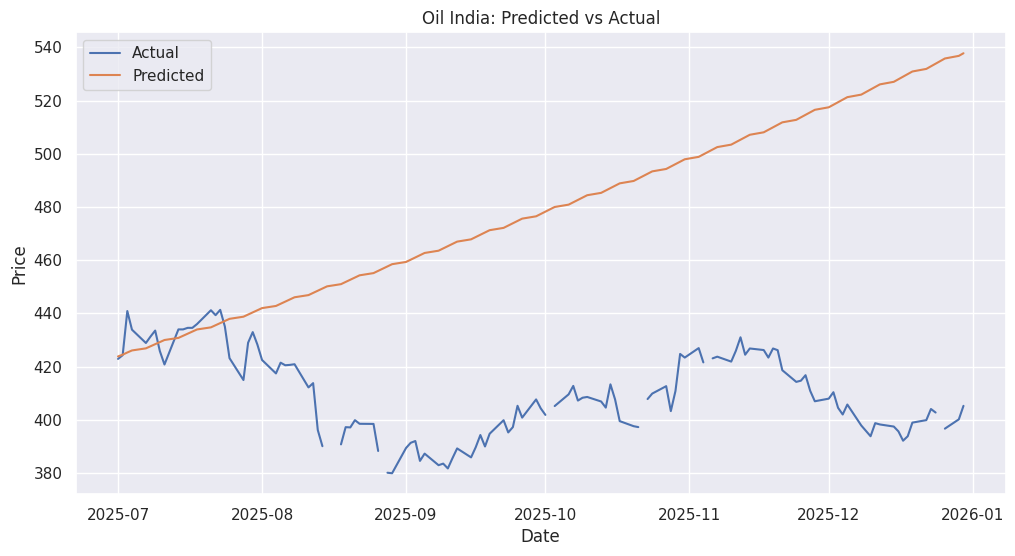

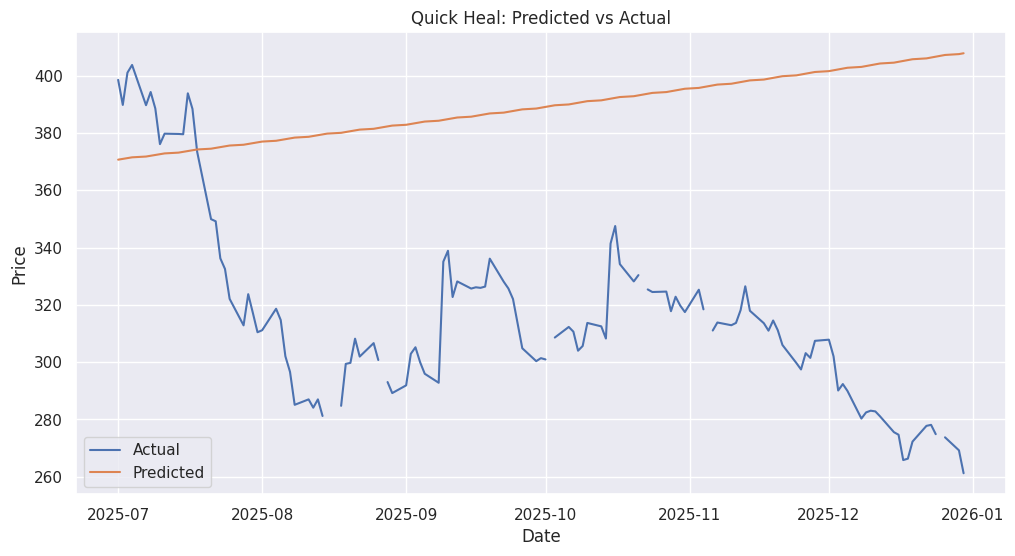

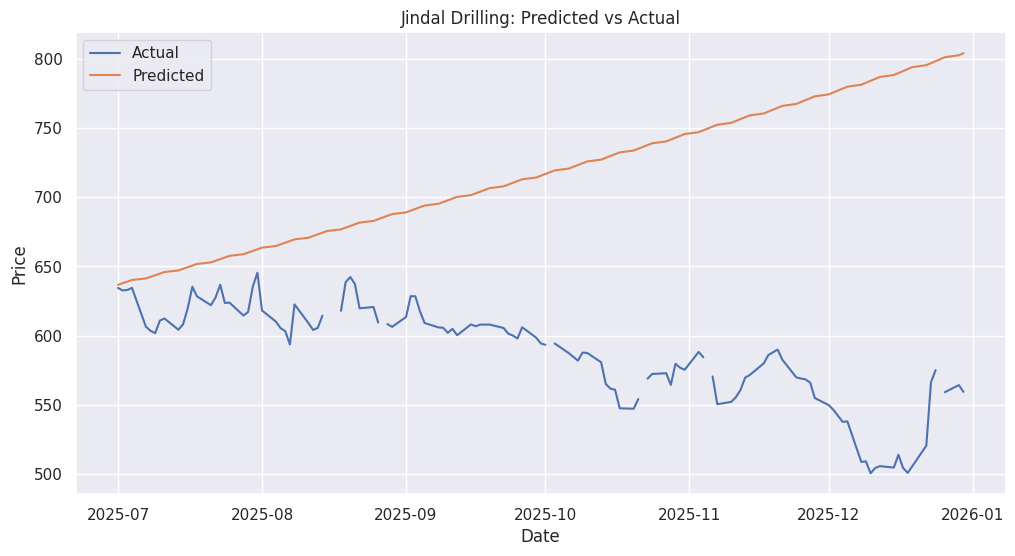

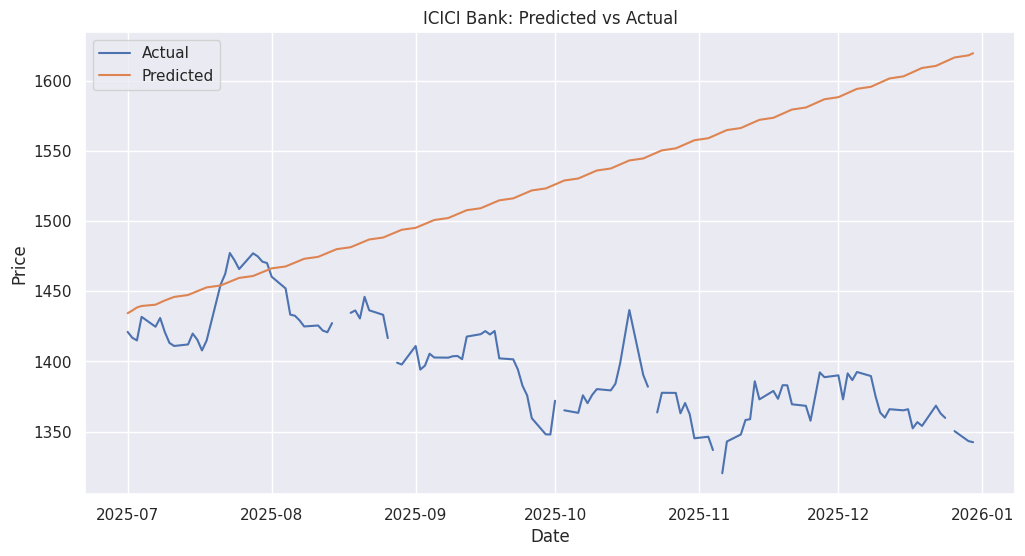

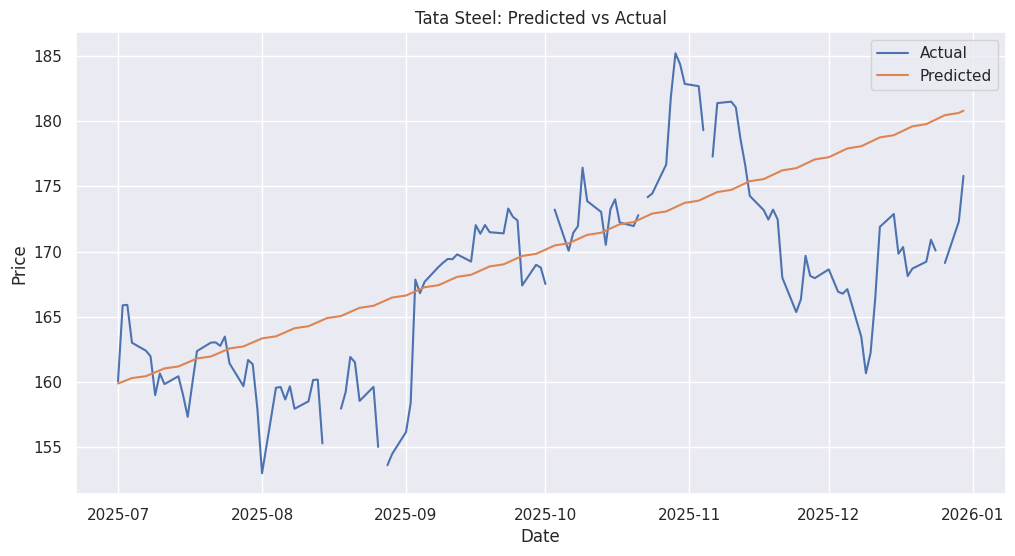

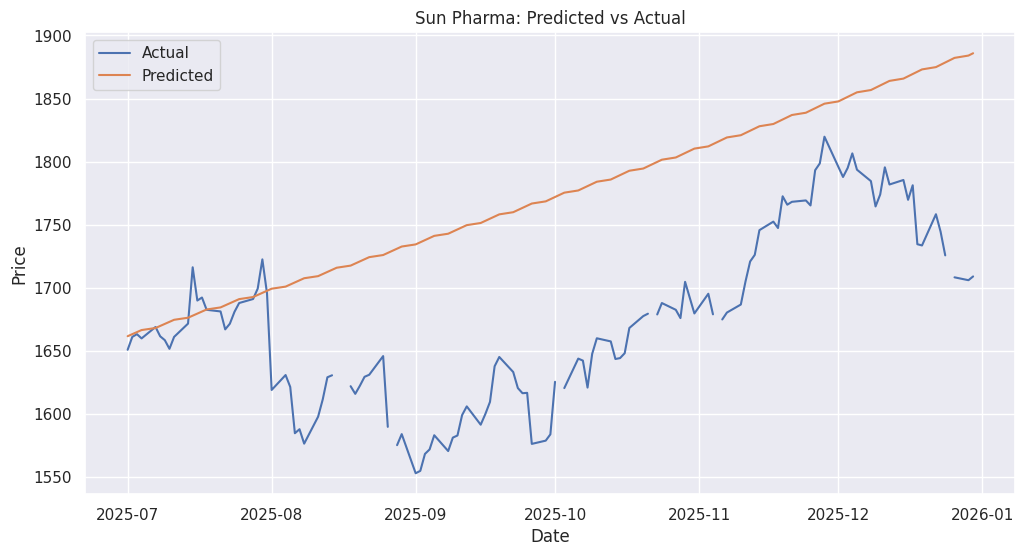


MODEL RANKING



,Stock,RMSE,MAPE (%),Direction Accuracy (%),Category,RMSE Rank,MAPE Rank,Direction Rank,Final Score
4,Tata Steel,6.448160,3.019133,50.000000,Loser,1.0,1.0,2.0,1.333333
5,Sun Pharma,112.079692,5.930896,61.016949,Winner,4.0,2.0,1.0,2.333333
0,Oil India,79.852716,17.216404,49.152542,Loser,2.0,4.0,3.0,3.000000
2,Jindal Drilling,153.221424,23.020611,43.220339,Loser,5.0,5.0,4.0,4.666667
3,ICICI Bank,153.469223,9.430415,41.525424,Loser,6.0,3.0,5.0,4.666667
1,Quick Heal,82.898660,25.307760,40.677966,Loser,3.0,6.0,6.0,5.000000


In [11]:
# ============================================================
# VISUALIZATION + MODEL RANKING
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------
# 1. Predicted vs Actual Visualization
# ---------------------------
print("\n====================================================")
print("PREDICTED vs ACTUAL VISUALIZATION")
print("====================================================\n")

for stock in actual_df.columns:
    plt.figure()
    plt.plot(actual_df.index, actual_df[stock], label="Actual")
    plt.plot(pred_df.index, pred_df[stock], label="Predicted")
    
    plt.title(f"{stock}: Predicted vs Actual")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.show()


# ---------------------------
# 2. Model Ranking Table
# ---------------------------
print("\n====================================================")
print("MODEL RANKING")
print("====================================================\n")

ranking_df = summary_df.copy()

# Rank by RMSE (lower is better)
ranking_df["RMSE Rank"] = ranking_df["RMSE"].rank()

# Rank by MAPE (lower is better)
ranking_df["MAPE Rank"] = ranking_df["MAPE (%)"].rank()

# Rank by Direction Accuracy (higher is better)
ranking_df["Direction Rank"] = ranking_df["Direction Accuracy (%)"].rank(ascending=False)

# Final Combined Score
ranking_df["Final Score"] = (
    ranking_df["RMSE Rank"] +
    ranking_df["MAPE Rank"] +
    ranking_df["Direction Rank"]
) / 3

# Sort by best model
ranking_df = ranking_df.sort_values(by="Final Score")

display(ranking_df)